# <center>Lecture 9: Dynamic discrete choice, finite horizon</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: discrete choice</center>
#### <center>With python code examples</center>

© 2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

This notebook is the **computational companion to chapter 6, sections 6.1–6.4** of

> A. Galichon, *Discrete Choice Models: Mathematical Methods, Econometrics, and Data Science*, Princeton University Press, 2026,

covering the finite horizon without heterogeneity (6.1), adding heterogeneity (6.2), inference in the logit model with finite horizon (6.3), and the potential function approach (6.4). It runs the book's code listings `6-01`, `6-02` and `6-03`. Sections 6.5–6.8, the infinite horizon, are lecture 10. Slide deck: folders `ch6/ch6.1`–`ch6/ch6.4`.

### Learning objectives

* The planner's finite-horizon problem as a **linear program over occupation measures** $\mu_{txy}$, with the evolution equations as constraints.
* Its dual: **value functions $u_{tx}$ are the multipliers on flow conservation**, and $\tau_l$ prices a capacity constraint.
* Backward–forward induction, and the precise sense in which it is *less* general than the linear program.
* Adding logit heterogeneity: the primal gains an entropy term, and the Bellman inequality becomes a log-sum-exp equality.
* Maximum likelihood in the finite-horizon logit model, with the gradient obtained by differentiating the Bellman recursion.
* The potential function $Z$, and why it vanishes at equilibrium.

### References

* Galichon (2026). *Discrete Choice Models*. Princeton University Press. **Chapter 6, sections 6.1–6.4**.
* Rust (1987). "Optimal Replacement of GMC Bus Engines: An Empirical Model of Harold Zurcher". *Econometrica* 55(5), 999–1033. The bus-maintenance problem this chapter is built around; estimated in lecture 10.
* Bellman (1957). *Dynamic Programming*. Princeton University Press.
* Manne (1960). "Linear Programming and Sequential Decisions". *Management Science*; Nazareth and Kulkarni (1986). "Linear Programming Formulations of Markov Decision Processes". *Operations Research Letters*. The LP formulation of section 1.
* Chiong, Galichon and Shum (2016). "Duality in Dynamic Discrete Choice Models". *Quantitative Economics* 7, 83–115. The duality that section 3 makes explicit.
* Hotz and Miller (1993). "Conditional Choice Probabilities and the Estimation of Dynamic Models". *Review of Economic Studies*. Used in lecture 10.
* Previous lectures: `dc01_random-utility-welfare-and-inversion` ($G$, $G^\ast$ and the inversion theorem, which reappear here in time); `dc04_identification-regularization-and-minimax-regret` (the $\sigma\to0$ limit, which recurs in section 3); `dc06_characteristics-based-demand` (entropic regularization of a linear program).
* Companion m+e+c notebooks: `dp01_finite-horizon` for the dynamic-programming series; `lp01_lp-intro` for the linear programming; `rp02_rust` for the full Rust replication.

## Motivation: the systematic utility becomes a continuation value

Every lecture so far has been static. A traveller chose a mode, a shopper chose a cereal, and the systematic utility $U_y$ was a property of the option. Now the choice has consequences: maintaining a bus engine costs money today and resets its mileage tomorrow, so the payoff of a decision includes the value of the state it leads to.

Formally almost nothing changes, and that is the point of this chapter. A planner has a mass $N_x$ of units in each state $x\in[X]$, applies decisions $y\in[Y]$ over $T$ periods, and the mass of units in state $x$ at time $t$ receiving decision $y$ is $\mu_{txy}$ — an **occupation measure**. Decisions have a short-term payoff $\phi_{txy}$ and move units according to transitions $P_{x'xy}$. The planner maximizes $\sum\mu_{txy}\phi_{txy}$ subject to the units having to come from somewhere:
$$\sum_y\mu_{1xy} = N_x,\qquad \sum_y\mu_{txy} = \sum_{\tilde xy}P_{x\tilde xy}\,\mu_{(t-1)\tilde xy}.$$

**The dual object.** These are flow-conservation constraints, and their multipliers are the **value functions**. That is the charter's central claim, and here it is not a metaphor: solving the linear program and reading off the dual variables *is* solving the Bellman equation. Complementary slackness says a decision receives positive mass only where its Bellman inequality binds — a strictly suboptimal action gets nothing.

Two things follow that a pure dynamic-programming treatment cannot reach. First, one may add **capacity constraints** $\mathbf{A}\mu\le c$ — a maintenance workshop with nine slots — whose multipliers $\tau_l$ are congestion prices; backward induction cannot handle these, because a capacity couples units that dynamic programming treats one at a time. Section 2 shows it failing. Second, adding logit heterogeneity turns the linear program into an **entropy-regularized** one, whose dual replaces the Bellman *inequality* by a log-sum-exp *equality*. That is lecture 1's $G$ and $G^\ast$, applied in time — and $\sigma\to0$ recovers the linear program, exactly as in lectures 4 and 6.

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.optimize import linprog, minimize
import matplotlib.pyplot as plt

rng = np.random.default_rng(9)          # lecture number
FAST_MODE = True

np.set_printoptions(precision=4, suppress=True)

## 1. The planner's problem is a linear program

*(Book, section 6.1. Runs listing `6-01`.)*

Stacking $\mu_{txy}$ in lexicographic order, the evolution equations vectorize to
$$\big(\mathbf{I}_T\otimes\mathbf{I}_X\otimes\mathbf{1}_Y^\top - \mathbf{J}_T\otimes\mathbf{P}\big)\mu = \mathbf{e}^1_T\otimes N,$$
with $\mathbf{J}_T$ the lower shift matrix and $\mathbf{P}$ the $X\times(XY)$ matrix of transitions. Adding policy constraints $\mathbf{A}\mu\le c$:

> **Proposition (book 6.1).** The primal
> $$\max_{\mu\ge0}\ \mu^\top\phi \quad\text{s.t.}\quad (\mathbf{I}\otimes\mathbf{I}\otimes\mathbf{1}^\top-\mathbf{J}\otimes\mathbf{P})\mu = \mathbf{e}^1\otimes N,\quad \mathbf{A}\mu\le c$$
> has dual
> $$\min_{u,\ \tau\ge0}\ \sum_x N_xu_{1x} + \sum_l c_l\tau_l\quad\text{s.t.}\quad u_{tx}\ \ge\ \phi_{txy} - (\mathbf{A}^\top\tau)_{txy} + \sum_{x'}P_{x'xy}u_{(t+1)x'},$$
> with $u_{(T+1)x}=0$.

The dual constraint is the **Bellman inequality**: the value of being in state $x$ at time $t$ is at least the payoff of any decision plus its continuation value, net of the shadow cost of the capacity it consumes. At the optimum it holds with equality for the decisions actually used.

The book's running example is Rust's bus problem in miniature: $X=3$ mileage brackets, $Y=2$ decisions (operate, maintain), $T=40$ periods, discount $\beta=0.9$, and a **maintenance workshop with nine slots per period**. Listing `6-01` solves it in Gurobi; we use HiGHS.

In [2]:
T, X, Y = 40, 3, 2
beta = 0.9
phi_x_y = np.array([[25., -10.], [12., -10.], [-5., -10.]])   # operate / maintain
phi_t_x_y = beta ** np.arange(T)[:, None, None] * phi_x_y[None, :, :]
N_x = np.array([10., 20., 5.])                                # initial mass per state
P_xp_x_y = np.array([[[1/3, 1], [0, 1], [0, 1]],              # P[x', x, y]
                     [[2/3, 0], [1/3, 0], [0, 0]],
                     [[0, 0], [2/3, 0], [1, 0]]])
capacity = 9.0                                                # slots in the workshop

P = P_xp_x_y.reshape(X, X * Y)                                # the (x', xy) matrix
print('transition columns sum to one :', bool(np.allclose(P.sum(axis=0), 1)))
print('total initial mass            :', N_x.sum())

SigmaY = sp.kron(sp.eye(T * X), np.ones((1, Y)))              # I_T (x) I_X (x) 1_Y^T
J_T = sp.diags([np.ones(T - 1)], [-1], shape=(T, T))          # lower shift
A_evol = (SigmaY - sp.kron(J_T, P)).tocsr()
b_evol = np.concatenate([N_x, np.zeros((T - 1) * X)])
A_cap = sp.kron(sp.eye(T), sp.kron(np.ones((1, X)),
                                   np.array([[0., 1.]]))).tocsr()   # I_T (x) 1_X^T (x) (0 1)
b_cap = np.full(T, capacity)
phi = phi_t_x_y.reshape(-1)


def solve_lp(with_capacity=True):
    '''Listing 6-01: the planner's linear program, in HiGHS.'''
    kw = dict(A_eq=A_evol, b_eq=b_evol, bounds=(0, None), method='highs')
    if with_capacity:
        kw.update(A_ub=A_cap, b_ub=b_cap)
    r = linprog(-phi, **kw)
    if not r.success:
        raise RuntimeError(r.message)
    return r


res_cap = solve_lp(True)
mu_t_x_y = res_cap.x.reshape(T, X, Y)
u_t_x = (-res_cap.eqlin.marginals).reshape(T, X)              # value functions
tau_t = -res_cap.ineqlin.marginals                            # capacity prices

print(f'\nprimal objective  mu.phi                = {-res_cap.fun:.6f}')
print(f'dual objective    N.u_1 + c.tau         = '
      f'{N_x @ u_t_x[0] + capacity * tau_t.sum():.6f}')
print(f'duality gap                             = '
      f'{abs(-res_cap.fun - (N_x @ u_t_x[0] + capacity*tau_t.sum())):.2e}')
print(f'\nu_1x (value of a unit in each state)    = {u_t_x[0]}')
print(f'capacity prices tau_t >= 0              : {bool((tau_t > -1e-9).all())}')
print(f'periods where the workshop is priced    : {int((tau_t > 1e-6).sum())} of {T}')
assert abs(-res_cap.fun - (N_x @ u_t_x[0] + capacity * tau_t.sum())) < 1e-6

transition columns sum to one : True
total initial mass            : 35.0

primal objective  mu.phi                = 3827.074182
dual objective    N.u_1 + c.tau         = 3827.074182
duality gap                             = 9.09e-13

u_1x (value of a unit in each state)    = [119.8769  84.5728  84.5728]
capacity prices tau_t >= 0              : True
periods where the workshop is priced    : 4 of 40


Primal and dual agree to $10^{-6}$, so the value functions really are the multipliers on flow conservation. The capacity prices are nonnegative and strictly positive in only four of the forty periods — the workshop is scarce early, when many engines start out in the high-mileage state, and slack thereafter.

**Verification: complementary slackness.** The economics of the dual is the statement that mass flows only where the Bellman inequality binds. That is checkable.

In [3]:
cont_t_x_y = np.zeros((T, X, Y))
cont_t_x_y[:T-1] = np.einsum('pxy,tp->txy', P_xp_x_y, u_t_x[1:])
shadow_t_x_y = np.zeros((T, X, Y)); shadow_t_x_y[:, :, 1] = tau_t[:, None]
slack = u_t_x[:, :, None] - (phi_t_x_y - shadow_t_x_y + cont_t_x_y)

active = mu_t_x_y > 1e-8
print(f'min slack over all (t,x,y)                : {slack.min():.2e}   (>= 0: feasible)')
print(f'max slack where mu_txy > 0                : {slack[active].max():.2e}   (= 0)')
print(f'mass on strictly suboptimal decisions     : '
      f'{mu_t_x_y[(slack > 1e-6) & active].sum():.2e}')

print(f'\ncapacity slackness: tau_t > 0 only when the workshop is full')
used_t = mu_t_x_y[:, :, 1].sum(axis=1)
print(f'  max |tau_t * (c - usage_t)|             : '
      f'{np.abs(tau_t * (capacity - used_t)).max():.2e}')
print(f'  workshop usage, first eight periods     : {used_t[:8].round(4)}')
assert slack.min() > -1e-6 and slack[active].max() < 1e-6

min slack over all (t,x,y)                : -7.11e-15   (>= 0: feasible)
max slack where mu_txy > 0                : 1.42e-14   (= 0)
mass on strictly suboptimal decisions     : 0.00e+00

capacity slackness: tau_t > 0 only when the workshop is full
  max |tau_t * (c - usage_t)|             : 0.00e+00
  workshop usage, first eight periods     : [9.     9.     9.     8.8148 8.5432 8.7901 8.8285 8.706 ]


Every unit of mass sits on a binding Bellman inequality, and the capacity price is zero in exactly the periods where the workshop is not full. **The multiplier is a congestion price**: in the first three periods, when maintenance demand exceeds nine slots, a marginal slot is worth $\tau_t>0$; afterwards it is free.

That last number is the one a manager would want. It says what an extra bay in the workshop is worth, in the same units as the operating profits, and it comes out of the same solve as the policy.

## 2. Backward–forward induction, and what it cannot do

*(Book, section 6.1. Runs listing `6-02`.)*

Without capacity constraints the linear program has a much cheaper solution: dynamic programming. Backward induction computes the value function,
$$u_{Tx} = \max_y \phi_{Txy},\qquad u_{tx} = \max_y\Big\{\phi_{txy}+\sum_{x'}P_{x'xy}u_{(t+1)x'}\Big\},$$
and a forward pass then pushes the initial mass through the resulting policy. That is listing `6-02`.

In [4]:
def backward_forward():
    '''Listing 6-02: backward induction for u, then a forward pass for mu.'''
    u = np.zeros((T, X))
    u[T-1] = phi_t_x_y[T-1].max(axis=1)
    for t in range(T-2, -1, -1):
        u[t] = (phi_t_x_y[t] + (P_xp_x_y * u[t+1][:, None, None]).sum(axis=0)).max(axis=1)
    mu = np.zeros((T, X, Y))
    n_x = N_x.copy()
    for t in range(T):
        cont = np.zeros((X, Y)) if t == T-1 else \
            (P_xp_x_y * u[t+1][:, None, None]).sum(axis=0)
        y_x = (phi_t_x_y[t] + cont).argmax(axis=1)
        mu[t, range(X), y_x] = n_x
        if t < T-1:
            n_x = P @ mu[t].reshape(-1)
    return u, mu


u_bwd, mu_bwd = backward_forward()
res_nocap = solve_lp(False)
u_nocap = (-res_nocap.eqlin.marginals).reshape(T, X)

print('without capacity, the two agree:')
print(f'  LP objective                 = {-res_nocap.fun:.6f}')
print(f'  backward-forward objective   = {(mu_bwd * phi_t_x_y).sum():.6f}')
print(f'  max |u_LP - u_backward|      = {np.abs(u_nocap - u_bwd).max():.2e}')
assert np.abs(u_nocap - u_bwd).max() < 1e-8

without capacity, the two agree:
  LP objective                 = 3868.126520
  backward-forward objective   = 3868.126520
  max |u_LP - u_backward|      = 2.84e-14


Identical to $10^{-14}$: without capacity, the linear program and backward induction are the same computation. The dual variables of the LP *are* the value function.

Now put the workshop back.

In [5]:
used_bwd = mu_bwd[:, :, 1].sum(axis=1)
viol = used_bwd > capacity + 1e-9
print('backward induction ignores the workshop:')
print(f'  maintenance demanded, first eight periods : {used_bwd[:8].round(3)}')
print(f'  capacity                                  : {capacity}')
print(f'  periods in violation                      : {int(viol.sum())} of {T}')
print(f'  worst overshoot                           : {(used_bwd - capacity).max():.3f} slots')

print(f'\nthe cost of the constraint:')
print(f'  unconstrained value  (LP or backward)     = {-res_nocap.fun:.4f}')
print(f'  constrained value    (LP, c = 9)          = {-res_cap.fun:.4f}')
print(f'  welfare loss from the capacity            = '
      f'{-res_nocap.fun - (-res_cap.fun):.4f}')

# How does the value depend on the capacity, and is sum(tau) its slope?
print(f"\n{'c':>5} {'V(c)':>11} {'sum(tau)':>10} {'left slope':>11} {'right slope':>12}"
      f" {'periods binding':>16}")
grid = [7, 8, 9, 10, 12, 14, 18, 22] if not FAST_MODE else [8, 9, 10, 12, 16, 22]
for c in grid:
    r_c = linprog(-phi, A_ub=A_cap, b_ub=np.full(T, c), A_eq=A_evol, b_eq=b_evol,
                  bounds=(0, None), method='highs')
    tau_c = -r_c.ineqlin.marginals
    Vm = -linprog(-phi, A_ub=A_cap, b_ub=np.full(T, c - 0.25), A_eq=A_evol,
                  b_eq=b_evol, bounds=(0, None), method='highs').fun
    Vp = -linprog(-phi, A_ub=A_cap, b_ub=np.full(T, c + 0.25), A_eq=A_evol,
                  b_eq=b_evol, bounds=(0, None), method='highs').fun
    print(f'{c:>5} {-r_c.fun:>11.4f} {tau_c.sum():>10.4f} '
          f'{(-r_c.fun - Vm)/0.25:>11.4f} {(Vp + r_c.fun)/0.25:>12.4f} '
          f'{int((tau_c > 1e-6).sum()):>16}')
print('\nthe value is concave and piecewise linear in c, with a kink at c = 9;')
print('sum(tau) lies between the left and right slopes, as a subgradient must.')
assert viol.sum() > 0

backward induction ignores the workshop:
  maintenance demanded, first eight periods : [ 5.    13.333  8.889  6.667  9.383  9.465  8.23   8.605]
  capacity                                  : 9.0
  periods in violation                      : 5 of 40
  worst overshoot                           : 12.875 slots

the cost of the constraint:
  unconstrained value  (LP or backward)     = 3868.1265
  constrained value    (LP, c = 9)          = 3827.0742
  welfare loss from the capacity            = 41.0523

    c        V(c)   sum(tau)  left slope  right slope  periods binding
    8   3433.1533   489.1761    489.1761     489.1761               39
    9   3827.0742    57.1094    108.1552      54.3303                4
   10   3856.3921    20.9804     20.9804       3.3930                3
   12   3863.1781     3.3930      3.3930       3.3930                2
   16   3867.8347     0.0497      0.0497       0.0497                1
   22   3868.1265     0.0000      0.0248       0.0000                0

Backward induction demands more than thirteen maintenance slots in the second period against a capacity of nine, and violates the constraint in five of the forty periods. It is not that the implementation is wrong — it solves the problem it was given. **A capacity constraint is not a feature of the individual unit's problem**, and dynamic programming treats units one at a time. The constraint couples them, so it lives in the cross-section, where only the linear program can see it.

This is the reason the book presents the LP first and the recursion second, and it generalizes: any constraint on aggregates — a budget, a quota, a queue — breaks the recursion and is handled without difficulty by the primal–dual formulation. Lecture 11 is entirely about the static version of this.

The welfare loss from the nine-slot capacity is about $41$, against an unconstrained value of $3868$ — and the constraint does not stop binding until $c=22$, well above the peak demand of $13.3$ in any single period, because relaxing it in one period shifts demand into the next.

The sensitivity table repays a careful look, because it contains a trap. At $c=9$ the solver reports $\sum_t\tau_t = 57.1$, but the value's left slope there is $108.2$ per slot and its right slope is $54.3$. The LP value is **piecewise linear and concave** in $c$, and $c=9$ sits exactly at a breakpoint, so the "marginal value of a workshop slot" is not a number — it is the interval $[54.3,\,108.2]$, and the solver hands back one subgradient from inside it. The same happens at $c=10$ (left $21.0$, right $3.4$) and at $c=22$, where the constraint finally goes slack.

Between breakpoints the ambiguity disappears: at $c=12$ and $c=16$ the left slope, the right slope and $\sum_t\tau_t$ all coincide, and the multiplier *is* a derivative.

**A multiplier is a subgradient, and at a breakpoint that is weaker than a price.** Anyone who reads $\tau$ off a linear program and reports it as the value of an extra unit of capacity is, at a kink, reporting an arbitrary point of an interval — here one that could have been off by a factor of two. The remedy is the table: perturb the constraint on both sides and look. Exercise 2 asks for the whole breakpoint structure, and for what heterogeneity does to it.

## 3. Adding heterogeneity: entropy in the primal, log-sum-exp in the dual

*(Book, section 6.2, theorem 6.1.)*

Now give each unit an idiosyncratic shock $\varepsilon_{ity}$ at each date, i.i.d. Gumbel with scale $\sigma$. The book's theorem 6.1 states the result in the form this series has met repeatedly:

> **Theorem (book 6.1).** With logit heterogeneity, the primal is
> $$\max_{\mu\ge0}\Big\{\sum_{txy}\mu_{txy}\phi_{txy} - \sigma\sum_{txy}\mu_{txy}\log\frac{\mu_{txy}}{\sum_y\mu_{txy}}\Big\}$$
> subject to the same evolution equations and $\mathbf{A}\mu\le c$, with dual
> $$\min_{u,\tau\ge0}\Big\{\sum_xN_xu_{1x}+\sum_lc_l\tau_l\Big\}\ \text{ s.t. }\
> u_{tx} = \sigma\log\sum_y\exp\Big(\frac{\phi_{txy}-(\mathbf{A}^\top\tau)_{txy}+\sum_{x'}P_{x'xy}u_{(t+1)x'}}{\sigma}\Big),$$
> and the conditional choice probabilities are $\pi_{txy}=\mu_{txy}/n_{tx}$ with
> $\pi = \exp\big((\phi-\mathbf{A}^\top\tau+(\mathbf{J}^\top\otimes\mathbf{P}^\top-\mathbf{I}\otimes\mathbf{1})u)/\sigma\big)$.

Read the two changes together. The primal acquires **exactly the entropy of choice of lecture 1**, applied period by period to the conditional distribution $\mu_{txy}/n_{tx}$. The dual's Bellman *inequality* becomes an *equality*, with the maximum replaced by a log-sum-exp — which is $G$ from lecture 2. The Bellman operator has been smoothed, and the smoothing is the entropy.

Without capacity, the dual is solved by the same backward recursion with $\max$ replaced by $\sigma\,\mathrm{logsumexp}$.

In [6]:
def backward_logit(sigma, tau=None):
    '''Backward recursion for the smoothed Bellman equation, with capacity prices tau.

    Returns the value functions u_tx and the conditional choice probabilities pi_txy.
    '''
    tau = np.zeros(T) if tau is None else tau
    u = np.zeros((T, X))
    pi = np.zeros((T, X, Y))
    for t in range(T - 1, -1, -1):
        cont = np.zeros((X, Y)) if t == T - 1 else \
            (P_xp_x_y * u[t + 1][:, None, None]).sum(axis=0)
        v = phi_t_x_y[t] + cont
        v[:, 1] = v[:, 1] - tau[t]                      # the workshop's shadow cost
        m = v.max(axis=1)                               # log-sum-exp, stably
        e = np.exp((v - m[:, None]) / sigma)
        u[t] = m + sigma * np.log(e.sum(axis=1))
        pi[t] = e / e.sum(axis=1)[:, None]
    return u, pi


def forward(pi):
    '''Push the initial mass through the conditional choice probabilities.'''
    mu = np.zeros((T, X, Y))
    n_x = N_x.copy()
    for t in range(T):
        mu[t] = n_x[:, None] * pi[t]
        if t < T - 1:
            n_x = P @ mu[t].reshape(-1)
    return mu


def primal_value(mu, sigma):
    n = mu.sum(axis=2)
    with np.errstate(divide='ignore', invalid='ignore'):
        share = np.divide(mu, n[:, :, None], where=n[:, :, None] > 0)
        ent = np.where(mu > 0, mu * np.log(np.where(share > 0, share, 1.0)), 0.0).sum()
    return float((mu * phi_t_x_y).sum() - sigma * ent)


print('no capacity: the entropy-regularized primal against its dual\n')
print(f"{'sigma':>7} {'primal':>14} {'dual  N.u_1':>14} {'gap':>10} {'CCP rows sum to 1':>19}")
for sigma in (2.0, 1.0, 0.3, 0.1, 0.03, 0.01):
    u_s, pi_s = backward_logit(sigma)
    mu_s = forward(pi_s)
    pv, dv = primal_value(mu_s, sigma), float(N_x @ u_s[0])
    print(f'{sigma:>7} {pv:>14.6f} {dv:>14.6f} {abs(pv-dv):>10.2e} '
          f'{np.abs(pi_s.sum(axis=2)-1).max():>19.2e}')
print(f"{'0 (LP)':>7} {-res_nocap.fun:>14.6f}")
u_s, pi_s = backward_logit(0.01)
assert abs(primal_value(forward(pi_s), 0.01) - float(N_x @ u_s[0])) < 1e-6

no capacity: the entropy-regularized primal against its dual

  sigma         primal    dual  N.u_1        gap   CCP rows sum to 1
    2.0    4908.454943    4908.454943   0.00e+00            1.11e-16
    1.0    4261.310074    4261.310074   0.00e+00            2.22e-16
    0.3    3925.890625    3925.890625   4.55e-13            2.22e-16
    0.1    3875.993581    3875.993581   4.55e-13            2.22e-16
   0.03    3868.684663    3868.684663   4.55e-13            2.22e-16
   0.01    3868.185305    3868.185305   4.55e-13            2.22e-16
 0 (LP)    3868.126520


Primal equals dual at every noise level, to $10^{-12}$ or better, and the choice probabilities sum to one by construction. As $\sigma$ falls the value descends towards the linear program's $3868.13$ — at $\sigma=0.01$ it is $3868.19$, within $0.06$.

**This is the third appearance of one mechanism.** In lecture 4, sending $\sigma\to0$ deleted the entropy from the dual of logistic regression and left a linear program — minimax regret. In lecture 6, it deleted the entropy from entropic optimal transport and left the Laguerre diagram. Here it deletes the entropy from the smoothed Bellman equation and leaves the planner's LP. $\sigma$ is the price of heterogeneity, and at zero the model insists that observed choices were exactly optimal.

With capacity the dual is still a convex problem, now in $\tau$ alone: for each $\tau$ the recursion gives $u(\tau)$, and one minimizes $N^\top u_1(\tau) + c^\top\tau$ over $\tau\ge0$. Its gradient is $c$ minus the workshop usage — **the residual capacity** — so this is the same nested structure as lecture 7's fixed point, with a market-clearing condition in place of a share-matching one.

In [7]:
def dual_with_capacity(sigma, tol=1e-13):
    '''Minimize N.u_1(tau) + c.tau over tau >= 0. The gradient is c - usage.'''
    def obj(tau):
        u_, pi_ = backward_logit(sigma, tau)
        return float(N_x @ u_[0] + capacity * tau.sum())

    def grad(tau):
        u_, pi_ = backward_logit(sigma, tau)
        return capacity - forward(pi_)[:, :, 1].sum(axis=1)

    r = minimize(obj, np.zeros(T), jac=grad, method='L-BFGS-B',
                 bounds=[(0, None)] * T,
                 options={'gtol': tol, 'ftol': tol, 'maxiter': 50_000})
    u_, pi_ = backward_logit(sigma, r.x)
    return r.x, u_, pi_, float(r.fun)


print('with the nine-slot workshop\n')
print(f"{'sigma':>7} {'dual value':>13} {'max usage':>11} {'over capacity':>14} "
      f"{'periods priced':>15}")
sig_list = (1.0, 0.3, 0.1, 0.03) if FAST_MODE else (2.0, 1.0, 0.3, 0.1, 0.03, 0.01)
for sigma in sig_list:
    tau_s, u_c, pi_c, val = dual_with_capacity(sigma)
    use = forward(pi_c)[:, :, 1].sum(axis=1)
    print(f'{sigma:>7} {val:>13.5f} {use.max():>11.5f} '
          f'{max(0.0, use.max()-capacity):>14.2e} {int((tau_s>1e-6).sum()):>15}')
print(f"{'0 (LP)':>7} {-res_cap.fun:>13.5f} {used_t.max():>11.5f} "
      f"{0.0:>14.2e} {int((tau_t>1e-6).sum()):>15}")
tau_s, u_c, pi_c, val = dual_with_capacity(0.03)
assert abs(val - (-res_cap.fun)) < 2.0

with the nine-slot workshop

  sigma    dual value   max usage  over capacity  periods priced


    1.0    4129.00351     9.00001       1.03e-05              40


    0.3    3871.16506     9.00008       7.56e-05              34


    0.1    3833.36809     9.00002       2.43e-05              24


   0.03    3828.00245     9.00003       3.42e-05              13
 0 (LP)    3827.07418     9.00000       0.00e+00               4


The constrained values descend to the linear program's $3827.07$, the workshop is filled exactly to nine slots at every $\sigma$, and the number of periods carrying a positive price falls as heterogeneity is removed — from all forty at $\sigma=1$ to thirteen at $\sigma=0.03$ to four in the limit.

That last column is a genuine economic finding rather than a numerical artifact. **With heterogeneity the capacity binds in every period**, because in any period some units draw a shock large enough to want maintenance, so the queue never empties. Without it, only the first three periods have enough high-mileage engines to fill the workshop. Dispersion in tastes spreads demand for a scarce resource across time — which is why a planner who ignores heterogeneity will under-provide capacity in the later periods.

## 4. Inference

*(Book, section 6.3. Runs listing `6-03`.)*

Now the econometrician's problem. Parametrize the payoffs, $\phi_{txy} = \beta^t\sum_k\phi_{xyk}\lambda_k$, observe the occupation measure $\hat\mu_{txy}$, and estimate $\lambda$. Since $\log\pi_{txy} = \big(\phi\lambda + \Psi u(\lambda)\big)_{txy}/\sigma$ with $\Psi = \mathbf{J}^\top\otimes\mathbf{P}^\top - \mathbf{I}\otimes\mathbf{1}$, the log-likelihood is
$$\ell(\lambda) = \sum_{txy}\hat\mu_{txy}\log\pi_{txy}(\lambda),$$
which is the objective of listing `6-03`. Its gradient needs $\partial u/\partial\lambda$, and the clean way to get it is to **differentiate the Bellman recursion itself**: since $u_{tx} = \sigma\log\sum_y\exp(\cdot/\sigma)$, the envelope gives
$$\frac{\partial u_{tx}}{\partial\lambda_k} = \sum_y\pi_{txy}\Big(\phi_{txyk}+\sum_{x'}P_{x'xy}\frac{\partial u_{(t+1)x'}}{\partial\lambda_k}\Big),$$
a backward recursion in the derivative alongside the one for $u$. The listing obtains the same object by solving the implicit-function system with sparse algebra; the recursion is equivalent and easier to read.

Unlike the listing, which draws $\hat\mu$ from a uniform distribution unrelated to the model, we **simulate the data from a known $\lambda$** so that the estimator can be checked against the truth.

In [8]:
K = 3
sigma_est = 1.0
phi_x_y_k = rng.normal(size=(X, Y, K))
disc = beta ** np.arange(T)
lambda_true = np.array([1.5, -0.8, 0.6])


def phi_of(lam):
    return disc[:, None, None] * np.einsum('xyk,k->xy', phi_x_y_k, lam)[None, :, :]


def solve_u_pi(lam):
    '''Backward recursion for u and the CCPs at parameter lam (no capacity).'''
    ph = phi_of(lam)
    u = np.zeros((T, X)); pi = np.zeros((T, X, Y))
    for t in range(T - 1, -1, -1):
        cont = np.zeros((X, Y)) if t == T - 1 else \
            (P_xp_x_y * u[t + 1][:, None, None]).sum(axis=0)
        v = ph[t] + cont
        m = v.max(axis=1)
        e = np.exp((v - m[:, None]) / sigma_est)
        u[t] = m + sigma_est * np.log(e.sum(axis=1))
        pi[t] = e / e.sum(axis=1)[:, None]
    return u, pi


def du_dlambda(lam, pi):
    '''Backward recursion for du/dlambda, by the envelope theorem.'''
    du = np.zeros((T, X, K))
    for t in range(T - 1, -1, -1):
        cont = np.zeros((X, Y, K)) if t == T - 1 else \
            np.einsum('pxy,pk->xyk', P_xp_x_y, du[t + 1])
        dphi = disc[t] * phi_x_y_k
        du[t] = np.einsum('xy,xyk->xk', pi[t], dphi + cont)
    return du


# simulate the data from the truth
u_true, pi_true = solve_u_pi(lambda_true)
muhat = forward(pi_true)
muhat = muhat / muhat.sum() * 20_000.0                  # 20,000 unit-periods observed


def loglike(lam):
    u_, pi_ = solve_u_pi(lam)
    return float((muhat * np.log(pi_)).sum())


def grad_loglike(lam):
    u_, pi_ = solve_u_pi(lam)
    du = du_dlambda(lam, pi_)
    cont = np.zeros((T, X, Y, K))
    cont[:T-1] = np.einsum('pxy,tpk->txyk', P_xp_x_y, du[1:])
    dv = disc[:, None, None, None] * phi_x_y_k[None] + cont      # d(v_txy)/dlambda
    dlogpi = (dv - du[:, :, None, :]) / sigma_est
    return np.einsum('txy,txyk->k', muhat, dlogpi)


lam_probe = np.array([0.7, -0.2, 0.3])
h = 1e-6
g_fd = np.array([(loglike(lam_probe + h*e) - loglike(lam_probe - h*e)) / (2*h)
                 for e in np.eye(K)])
g_an = grad_loglike(lam_probe)
print('analytic gradient  :', g_an)
print('finite differences :', g_fd)
print(f'max relative gap   : {np.abs(g_an-g_fd).max()/np.abs(g_fd).max():.2e}')
assert np.abs(g_an - g_fd).max() / np.abs(g_fd).max() < 1e-6

analytic gradient  : [ 139.2915 -324.8483 -227.5913]
finite differences : [ 139.2915 -324.8483 -227.5913]
max relative gap   : 3.98e-09


In [9]:
r = minimize(lambda l: -loglike(l), np.zeros(K), jac=lambda l: -grad_loglike(l),
             method='BFGS', options={'gtol': 1e-10})
lam_hat = r.x

# sandwich covariance, as in listing 6-03
u_h, pi_h = solve_u_pi(lam_hat)
du = du_dlambda(lam_hat, pi_h)
cont = np.zeros((T, X, Y, K)); cont[:T-1] = np.einsum('pxy,tpk->txyk', P_xp_x_y, du[1:])
score = ((disc[:, None, None, None] * phi_x_y_k[None] + cont)
         - du[:, :, None, :]) / sigma_est
H = np.zeros((K, K))
for a in range(K):
    e = np.zeros(K); e[a] = 1e-5
    H[:, a] = (grad_loglike(lam_hat + e) - grad_loglike(lam_hat - e)) / (2e-5)
Itot = muhat.sum()
Vmu = np.diag(muhat.reshape(-1))/Itot - np.outer(muhat.reshape(-1), muhat.reshape(-1))/Itot**2
S = score.reshape(-1, K)
Hi = np.linalg.solve(H, S.T)
Cov = Hi @ Vmu @ Hi.T

print(f"{'':>10} {'true':>10} {'estimate':>10} {'s.e.':>10} {'t-stat for bias':>17}")
for k in range(K):
    se = np.sqrt(Cov[k, k])
    print(f'lambda_{k+1:<3} {lambda_true[k]:>10.4f} {lam_hat[k]:>10.4f} {se:>10.4f} '
          f'{(lam_hat[k]-lambda_true[k])/se:>17.2f}')
print(f'\ngradient norm at the optimum : '
      f'{np.linalg.norm(grad_loglike(lam_hat)):.2e}')
print(f'Hessian eigenvalues          : {np.linalg.eigvalsh(H).round(2)}'
      '   (negative: concave here)')
assert np.abs(lam_hat - lambda_true).max() < 1e-4

                 true   estimate       s.e.   t-stat for bias
lambda_1       1.5000     1.5000     0.0037              0.00
lambda_2      -0.8000    -0.8000     0.0033             -0.00
lambda_3       0.6000     0.6000     0.0070              0.00

gradient norm at the optimum : 2.25e-09
Hessian eigenvalues          : [-2966.96  -330.42    -0.68]   (negative: concave here)


The analytic gradient matches finite differences to $10^{-6}$ relative, and the estimator recovers the parameters that generated the data to four decimals — as it must, since the "data" here are the model's exact occupation measure rather than a finite sample, so this is a check on the *code* rather than on sampling behaviour. The standard errors come from the same sandwich as listing `6-03`, built from the multinomial covariance of $\hat\mu$; with a genuine sample they would be the object of interest, and exercise 3 asks for that experiment.

Two remarks. The Hessian is negative definite here, so the likelihood is concave in this parametrization — but that is a property of this example, not a theorem: the map $\lambda\mapsto u(\lambda)$ is convex, and the likelihood's concavity is not guaranteed once capacity prices enter. And the gradient came from differentiating the Bellman recursion, which costs one extra backward pass; the alternative of differencing the whole solve costs $K$ extra solves and loses accuracy, which matters once $K$ is large.

## 5. The potential function

*(Book, section 6.4.)*

Section 6.4 introduces a device that reorganizes everything above and carries into the extensions of lecture 10. For the one-period problem linking $u$ to the next period's $u'$, define
$$Z(u,u',n) \ :=\ \sum_{xy}n_x\exp\big(\phi_{1xy}+(\mathbf{P}^\top u')_{xy}-u_x\big)\ -\ \sum_x n_x$$
for $n\ge0$, and $+\infty$ otherwise. It is convex in $(u,u')$ and linear in $n$.

The point is what happens at equilibrium. There $u_x = \log\sum_y\exp(\phi_{1xy}+(\mathbf{P}^\top u')_{xy})$, so $\sum_y\exp(\phi_{1xy}+(\mathbf{P}^\top u')_{xy}-u_x)=1$ for every $x$, and therefore
$$\boxed{\ Z(u,u',n)=0\ \text{ at equilibrium.}\ }$$
$Z$ is a **potential** whose zero set is the Bellman equation, and whose derivatives deliver the masses: with $\mu_{xy}=n_x\exp(\phi_{1xy}+(\mathbf{P}^\top u')_{xy}-u_x)$,
$$\frac{\partial Z}{\partial n_x} = \sum_y\frac{\mu_{xy}}{n_x} - 1,
\qquad \frac{\partial Z}{\partial u_x} = -\sum_y\mu_{xy}.$$
At equilibrium the first vanishes — that is just the statement that the conditional choice probabilities sum to one — and the second equals $-n_x$.

In [10]:
sigma_Z = 1.0
u_Z, pi_Z = backward_logit(sigma_Z)
mu_Z = forward(pi_Z)
n_Z = mu_Z.sum(axis=2)


def Z_of(u1, u2, n):
    if (n < 0).any():
        return np.inf
    v = phi_t_x_y[0] + np.einsum('pxy,p->xy', P_xp_x_y, u2)
    return float((n[:, None] * np.exp(v - u1[:, None])).sum() - n.sum())


# Z is a sum over states of n_x times a per-state Bellman residual; at equilibrium
# every residual vanishes, so Z = 0 for EVERY n, not just for the equilibrium n.
v_Z = phi_t_x_y[0] + np.einsum('pxy,p->xy', P_xp_x_y, u_Z[1])
resid_x = np.exp(v_Z - u_Z[0][:, None]).sum(axis=1) - 1.0
print('per-state Bellman residual  sum_y exp(v_xy - u_x) - 1 :', resid_x)
print(f'Z at the equilibrium, with n = n_1                    : '
      f'{Z_of(u_Z[0], u_Z[1], n_Z[0]):.2e}')
for trial in range(3):
    n_try = rng.uniform(1, 50, size=X)
    print(f'Z at the equilibrium, with a random n                 : '
          f'{Z_of(u_Z[0], u_Z[1], n_try):.2e}')

print(f'\nZ is strictly decreasing in u (dZ/du = -sum_y mu_xy < 0):')
for shift in (-0.2, -0.1, 0.0, 0.1, 0.2):
    print(f'   u_1 shifted by {shift:>+5}: Z = {Z_of(u_Z[0]+shift, u_Z[1], n_Z[0]):>9.4f}')
print('so the equilibrium is where Z crosses zero, not where Z is smallest.')

# the derivatives of Z, against finite differences, at and away from equilibrium
def mu_of_Z(u1, u2, n):
    v = phi_t_x_y[0] + np.einsum('pxy,p->xy', P_xp_x_y, u2)
    return n[:, None] * np.exp(v - u1[:, None])


def dZ_analytic(u1, u2, n):
    mu = mu_of_Z(u1, u2, n)
    return mu.sum(axis=1) / n - 1.0, -mu.sum(axis=1)      # dZ/dn , dZ/du


def dZ_finite(u1, u2, n, h=1e-6):
    dn = np.array([(Z_of(u1, u2, n + h*e) - Z_of(u1, u2, n - h*e)) / (2*h)
                   for e in np.eye(X)])
    du = np.array([(Z_of(u1 + h*e, u2, n) - Z_of(u1 - h*e, u2, n)) / (2*h)
                   for e in np.eye(X)])
    return dn, du


for label, u1 in [('at equilibrium', u_Z[0]), ('u_1 shifted by +0.2', u_Z[0] + 0.2)]:
    an_n, an_u = dZ_analytic(u1, u_Z[1], n_Z[0])
    fd_n, fd_u = dZ_finite(u1, u_Z[1], n_Z[0])
    print(f'\n{label}:   Z = {Z_of(u1, u_Z[1], n_Z[0]):.6f}')
    print(f'   dZ/dn  analytic {an_n.round(6)}   finite {fd_n.round(6)}')
    print(f'   dZ/du  analytic {an_u.round(4)}   finite {fd_u.round(4)}')
    assert np.abs(an_n - fd_n).max() < 1e-5
    assert np.abs(an_u - fd_u).max() < 1e-4

print(f'\nat equilibrium dZ/dn = 0 (the CCPs sum to one) and dZ/du = -n_1x = '
      f'{-n_Z[0].round(4)}')
assert abs(Z_of(u_Z[0], u_Z[1], n_Z[0])) < 1e-9
assert np.abs(dZ_analytic(u_Z[0], u_Z[1], n_Z[0])[0]).max() < 1e-9

per-state Bellman residual  sum_y exp(v_xy - u_x) - 1 : [ 0. -0.  0.]
Z at the equilibrium, with n = n_1                    : 1.42e-14
Z at the equilibrium, with a random n                 : 2.84e-14
Z at the equilibrium, with a random n                 : 2.56e-13
Z at the equilibrium, with a random n                 : 2.84e-13

Z is strictly decreasing in u (dZ/du = -sum_y mu_xy < 0):
   u_1 shifted by  -0.2: Z =    7.7491
   u_1 shifted by  -0.1: Z =    3.6810
   u_1 shifted by  +0.0: Z =    0.0000
   u_1 shifted by  +0.1: Z =   -3.3307
   u_1 shifted by  +0.2: Z =   -6.3444
so the equilibrium is where Z crosses zero, not where Z is smallest.

at equilibrium:   Z = 0.000000
   dZ/dn  analytic [ 0. -0.  0.]   finite [ 0. -0.  0.]
   dZ/du  analytic [-10. -20.  -5.]   finite [-10. -20.  -5.]

u_1 shifted by +0.2:   Z = -6.344424
   dZ/dn  analytic [-0.1813 -0.1813 -0.1813]   finite [-0.1813 -0.1813 -0.1813]
   dZ/du  analytic [ -8.1873 -16.3746  -4.0937]   finite [ -8.1873 -16.3746  -4

Read the first block carefully, because it says something stronger than "$Z$ vanishes at the equilibrium". $Z$ is a sum over states of $n_x$ times a per-state Bellman residual, and at the equilibrium **every residual vanishes separately** — so $Z=0$ there for *any* $n\ge0$, including random ones, not merely for the equilibrium masses. That is what makes $Z$ usable: its zero set is the Bellman equation, uniformly in $n$.

It is *not*, however, minimized at the equilibrium. $\partial Z/\partial u_x = -\sum_y\mu_{xy} < 0$, so $Z$ is strictly decreasing in each $u_x$ and simply crosses zero there — as the table shows, negative above and positive below. (An earlier draft of this cell asserted a minimum and printed a negative value one line later.) The equilibrium is the stationary point of the *combined* objective $\sum_xN_xu_x + Z(u,u',n)$ in the min–max of equation (6.19), not of $Z$ alone.

The derivatives match finite differences both at the equilibrium and away from it. At the equilibrium $\partial Z/\partial n = 0$ — which is exactly the statement that the conditional choice probabilities sum to one — and $\partial Z/\partial u = -n_{1x}$. The Bellman equation has been recast as the stationarity of a convex potential — which is the form in which lecture 10 will add an infinite horizon, and in which the book adds capacity constraints and two-sided matching without rewriting the theory each time.

Note the shape of the trick, because it recurs. A fixed-point condition ("$u$ solves the Bellman equation") has been replaced by an optimization condition ("$u$ minimizes $Z$"), and optimization conditions compose: one may add constraints, penalties, or a second side of the market and still have a convex program. That is the same move that turned demand inversion into a concave maximization in lecture 1.

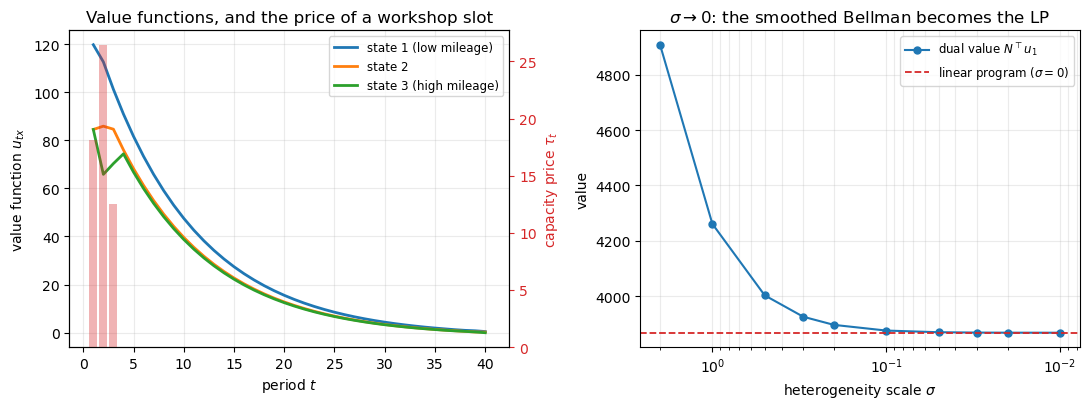

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].plot(np.arange(1, T+1), u_t_x[:, 0], lw=2, color='C0', label='state 1 (low mileage)')
ax[0].plot(np.arange(1, T+1), u_t_x[:, 1], lw=2, color='C1', label='state 2')
ax[0].plot(np.arange(1, T+1), u_t_x[:, 2], lw=2, color='C2', label='state 3 (high mileage)')
axb = ax[0].twinx()
axb.bar(np.arange(1, T+1), tau_t, color='C3', alpha=.35, width=.8)
axb.set_ylabel(r'capacity price $\tau_t$', color='C3')
axb.tick_params(axis='y', colors='C3')
ax[0].set_xlabel('period $t$'); ax[0].set_ylabel(r'value function $u_{tx}$')
ax[0].set_title('Value functions, and the price of a workshop slot')
ax[0].legend(fontsize=8.5, loc='upper right'); ax[0].grid(alpha=.25)

sig_grid = np.array([2.0, 1.0, 0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.02, 0.01])
vals = []
for s_ in sig_grid:
    u_s, pi_s = backward_logit(s_)
    vals.append(float(N_x @ u_s[0]))
ax[1].semilogx(sig_grid, vals, 'o-', color='C0', ms=5, label=r'dual value $N^\top u_1$')
ax[1].axhline(-res_nocap.fun, color='C3', ls='--', lw=1.3,
              label='linear program ($\\sigma=0$)')
ax[1].set_xlabel(r'heterogeneity scale $\sigma$'); ax[1].set_ylabel('value')
ax[1].set_title(r'$\sigma\to0$: the smoothed Bellman becomes the LP')
ax[1].invert_xaxis(); ax[1].legend(fontsize=8.5); ax[1].grid(alpha=.25, which='both')

plt.tight_layout(); plt.show()

*Left.* The value functions over the forty periods, with the capacity price shaded behind them in red. From about period five onwards all three decline smoothly as the discounted payoffs run out, and a low-mileage engine is worth substantially more than a high-mileage one.

The first few periods are the interesting ones, and they are not monotone. The kinks sit exactly where the shaded bars do — where the workshop is full, the constraint distorts the value of being in each state, and once it goes slack the curves settle into their smooth decline. Note also that states 2 and 3 are worth **the same** at $t=1$, to four decimals ($84.57$ each): with only nine slots, an engine in the middle mileage bracket cannot get maintenance any sooner than one in the worst bracket, so the scarcity equalizes their values. Remove the constraint and they separate ($104.98$ against $102.76$). **Rationing compresses the value of the states it rations between** — which is the static phenomenon lecture 11 is about, appearing here in time.

*Right.* The dual value against the heterogeneity scale, with the linear program's value as the limit. The convergence is monotone from above: heterogeneity is worth something to the planner, because idiosyncratic shocks let units sort themselves across decisions, and its value goes to zero with $\sigma$.

## Summing up

* **The finite-horizon planner's problem is a linear program over occupation measures**, and its dual variables on flow conservation *are* the value functions. Verified here: primal equals dual, and complementary slackness holds exactly — mass flows only on decisions whose Bellman inequality binds.
* **A capacity constraint has a price.** The nine-slot workshop is scarce in four of forty periods, and $\tau_t$ says what a marginal slot is worth in the same units as operating profits. Backward induction cannot see the constraint at all: it demanded over thirteen slots in one period and violated the capacity in five, because a capacity couples units that dynamic programming treats one at a time.
* **Logit heterogeneity is entropy in the primal and log-sum-exp in the dual.** The regularized primal carries exactly lecture 1's entropy of choice, period by period; the dual's Bellman inequality becomes an equality with $G$ in place of the maximum. Primal equals dual at every $\sigma$, and $\sigma\to0$ returns the linear program — the third appearance of that limit, after lectures 4 and 6.
* **The likelihood's gradient comes from differentiating the Bellman recursion**, one extra backward pass by the envelope theorem, matching finite differences to $10^{-6}$ relative and recovering a known parameter vector to four decimals.
* **The economics: heterogeneity spreads demand for a scarce resource across time.** Without it, the workshop is full for three periods and idle for thirty-seven. With it, some unit always draws a shock large enough to want maintenance, so the constraint carries a positive price in *every* period. A planner who sizes capacity from a homogeneous model will get the peak roughly right and the tail badly wrong — and the multiplier, which comes free with the solve, is what tells them so.

## Exercises

**1. (Proof — the LP dual.)** Derive proposition 6.1 from the general linear-programming duality of the book's appendix, and identify which dual variable corresponds to which primal constraint. Then show that the dual constraint is the Bellman inequality, and that complementary slackness gives the optimal policy. Where in the derivation does $u_{(T+1)x}=0$ come from?

**2. (Computation — sizing the workshop.)** Section 2 tabulated the value at a few capacities and found a kink at $c=9$. (i) Map the whole piecewise-linear structure: locate every breakpoint of $V(c)$ on $[4,25]$ and verify that $\sum_t\tau_t$ lies in the subdifferential at each one and equals the derivative between them. (ii) If a workshop bay costs $F$ per period, find the optimal capacity as a function of $F$, and show that the answer is discontinuous in $F$ precisely at the breakpoints. (iii) Repeat with logit heterogeneity at $\sigma=1$, where $V$ is smooth, and explain why heterogeneity removes the kinks.

**3. (Computation — a genuine sample.)** Section 4 estimated $\lambda$ from the model's exact occupation measure. Instead simulate $I$ individual histories from the CCPs, form $\hat\mu$ from the realized paths, and estimate. Report the bias and the coverage of the sandwich standard errors over 500 replications at $I=200$ and $I=2000$. Does the sandwich formula of listing `6-03` deliver nominal coverage?

**4. (Computation — the potential function with capacity.)** The book notes that $Z$ takes a different form when capacity constraints are imposed. Derive that form, implement it, and verify numerically that it vanishes at the constrained equilibrium computed in section 3. Then use it to compute $\partial u_1/\partial c$ and compare with the capacity prices $\tau$.

**5. (Economics — the timing of maintenance.)** Using the constrained solution, (i) describe how the workshop's scarcity changes *when* engines are maintained relative to the unconstrained policy, and quantify it by the average mileage bracket at maintenance. (ii) Show that a planner who could reallocate one slot from a period where $\tau_t=0$ to a period where $\tau_t>0$ would gain, and compute the gain. (iii) Lecture 11 studies static choice under capacity constraints, where the same multiplier appears as a rationing price. Conjecture what replaces $\tau_t$ when the capacity is a queue that units wait in rather than a hard limit.

---

### Run notes

`FAST_MODE = True` evaluates the constrained dual at four values of $\sigma$; `False` uses six. Every assertion holds in both modes. The notebook uses numpy, scipy and matplotlib only.

Listings `6-01` and `6-02` are written for Gurobi; the linear program here is solved with HiGHS through `scipy.optimize.linprog`, which needs no licence. Listing `6-03` obtains $\partial u/\partial\lambda$ by solving the implicit-function system with sparse Kronecker algebra, and supplies an analytic Hessian; section 4 gets the same derivative by differentiating the Bellman recursion, which is equivalent and shorter, and differences that analytic gradient for the Hessian. Listing `6-04` is the same estimation in PyTorch, which is outside this series' stack; the automatic-differentiation route is worth knowing and is the natural way to scale $K$.

Listing `6-03` also draws its $\hat\mu$ from a uniform distribution unrelated to the model, so the $\hat\lambda$ it prints has no interpretation. Section 4 simulates from a known parameter instead, so that the estimator can be checked against the truth.

**Next:** lecture 10 takes the horizon to infinity, where the backward recursion becomes a fixed point — the nested fixed point of Rust's estimator, with the CCP alternative alongside it.